Dataset shape: 25,063 rows × 14 columns

=== field_final Group Summary ===
  Total data points : 25,063
  Unique groups     : 5
  Missing values    : 0

  Group                             Count       %  Bar
  -----------------------------------------------------------------
  biology                          14,359   57.3%  ████████████████████████████
  social                            5,079   20.3%  ██████████
  medicine                          3,663   14.6%  ███████
  chemistry                         1,675    6.7%  ███
  other                               287    1.1%  

Full table:
field_final  count  percentage
    biology  14359       57.29
     social   5079       20.26
   medicine   3663       14.62
  chemistry   1675        6.68
      other    287        1.15


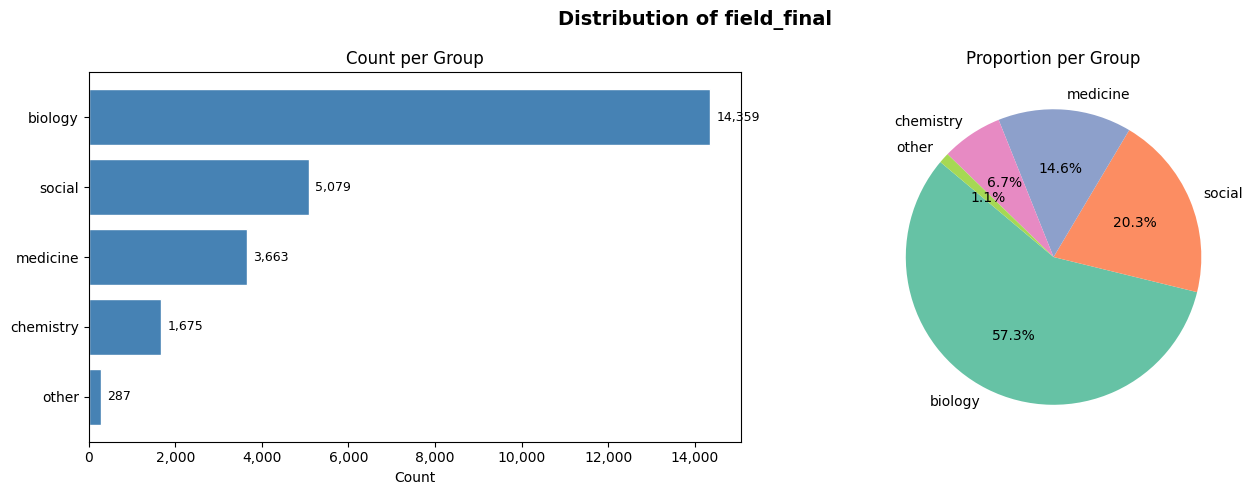

Chart saved to field_final_distribution.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── 1. Load Data ──────────────────────────────────────────────────────────────
df = pd.read_csv("train.csv")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

# ── 2. Group by field_final ───────────────────────────────────────────────────
group_counts = df["field_final"].value_counts().reset_index()
group_counts.columns = ["field_final", "count"]
group_counts["percentage"] = (group_counts["count"] / len(df) * 100).round(2)

# ── 3. Print Summary ──────────────────────────────────────────────────────────
print("=== field_final Group Summary ===")
print(f"  Total data points : {len(df):,}")
print(f"  Unique groups     : {df['field_final'].nunique()}")
print(f"  Missing values    : {df['field_final'].isna().sum()}")
print()
print(f"  {'Group':<30} {'Count':>8}  {'%':>6}  Bar")
print("  " + "-" * 65)
for _, row in group_counts.iterrows():
    bar = "█" * int(row["percentage"] / 2)
    print(
        f"  {str(row['field_final']):<30} {row['count']:>8,}  {row['percentage']:>5.1f}%  {bar}"
    )

print()
print("Full table:")
print(group_counts.to_string(index=False))

# ── 4. Visualise ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution of field_final", fontsize=14, fontweight="bold")

# Bar chart
ax1 = axes[0]
bars = ax1.barh(
    group_counts["field_final"].astype(str),
    group_counts["count"],
    color="steelblue",
    edgecolor="white",
)
ax1.set_xlabel("Count")
ax1.set_title("Count per Group")
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, val in zip(bars, group_counts["count"]):
    ax1.text(
        bar.get_width() + max(group_counts["count"]) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}",
        va="center",
        fontsize=9,
    )
ax1.invert_yaxis()

# Pie chart
ax2 = axes[1]
ax2.pie(
    group_counts["count"],
    labels=group_counts["field_final"].astype(str),
    autopct="%1.1f%%",
    startangle=140,
    colors=plt.cm.Set2.colors,
)
ax2.set_title("Proportion per Group")

plt.tight_layout()
plt.savefig("field_final_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to field_final_distribution.png")